# **Hugging Face Transformers Library** 🧠🤗

[Hugging Face](https://huggingface.co) is a leading open-source community. Their [Model Hub](https://huggingface.co/models) hosts a large collection of **pre-trained** deep learning models, primarily designed for **Natural Language Processing (NLP)** but also extending to **Computer Vision (CV)** and **Audio** tasks.

**Instructions**
- Write code in the space indicated with `### START CODE HERE ###`
- Do not use loops (for/while) unless instructions explicitly tell you so. Parallelization in Deep Learning is key!
- If you get stuck, ask for help in Slack or DM `@DRU Team`

**You will learn**
- How to use `pipeline()` from the [Models Hub](https://huggingface.co/models) for inference on a variety of NLP, CV, and Audio tasks
- How to use [Gradio](https://gradio.app/docs/) library for easy creating user interface and handling the pipeline inference directly on Google Colab notebook

## **Import packages**

In [ ]:
!pip install gradio sentence_transformers g2p_en

In [ ]:
!pip install git+https://github.com/One-sixth/fairseq.git

In [2]:
import nltk
nltk.download("averaged_perceptron_tagger_eng")

import torch
from torch import nn

import numpy as np
import pandas as pd

import transformers
from transformers import pipeline

import sentence_transformers
from sentence_transformers import SentenceTransformer, util

import gradio as gr

from PIL import Image
import matplotlib.pyplot as plt

from fairseq.checkpoint_utils import load_model_ensemble_and_task_from_hf_hub
from fairseq.models.text_to_speech.hub_interface import TTSHubInterface

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Dmytro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [3]:
# VALIDATION_FIELD[func] set_seed

def set_seed(seed):
    np.random.seed(seed) 
    torch.manual_seed(seed)

set_seed(42)

## **📌 List of Tasks Covered**

### **📝 NLP Tasks**
- **Masked Language Modeling**
- **Question Answering**
- **Table Question Answering**
- **Summarization**
- **Sentence Similarity**
- **Text Classification**
- **Token Classification**
- **Zero-Shot Classification**
- **Translation**
- **Text Generation**
- **Text-to-Text Generation**

### **🎙️ Audio Tasks**
- **Text-to-Speech (TTS)**
- **Automatic Speech Recognition (ASR)**

### **🖼️ Computer Vision Tasks**
- **Image Classification**
- **Image Segmentation**

---

## **🚀 Using `pipeline()` for Pre-Trained Models**

The **easiest** way to use a **pre-trained Transformer model** for any of these tasks is by using the `pipeline()` function from the 🤗 **Transformers** library.

The `pipeline()` **automates** the entire process by handling:

1. **Tokenization** – Splits the input into sub-word units (tokens).
2. **Inference** – Maps each token into a rich, contextual representation.
3. **Decoding** – Converts the processed tokens into a human-readable output tailored to the specific task.

📌 **Learn more about pipelines:** [Hugging Face Pipeline Tutorial](https://huggingface.co/docs/transformers/pipeline_tutorial)

---

## **NLP Tasks**

### **Masked language modeling**

[Masked Language Modeling](https://huggingface.co/tasks/fill-mask) (MLM) is an NLP task where certain tokens in a sequence are **masked** (e.g., replaced by `[MASK]`), and the model predicts the most likely words to replace them.

---

#### **Inference with Fill-Mask Pipeline**

You can use the Transformers library `fill-mask` pipeline to infer with masked language models, which you can find on the [Hugging Face Hub](https://huggingface.co/models?pipeline_tag=fill-mask&sort=downloads). There are many pretrained models here that can be used to solve the MLM task.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> For the given `masked_sequences`, find a **pretrained base BERT (uncased) model** on the [Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=fill-mask&sort=downloads) and use it in the **`fill-mask` pipeline** for inference.

🔹 **Requirements:**
- Your model should return **`top_k=2`** predictions for each sentence in `masked_sequences`.
- Refer to the pipeline parameters **[here](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.FillMaskPipeline)**.



In [4]:
# VALIDATION_FIELD[func] model_mlm

set_seed(42)

masked_sequences = [
    "I love animals very much, that's why I work as a [MASK].",
    "I lived several years in the UK, but now I live in [MASK].",
    "I love to play [MASK], so my bought me a ball."
]

### START CODE HERE ### (≈ 2-4 lines of code)
model_mlm = pipeline(
    task="fill-mask",
    model="google-bert/bert-base-uncased",
)                                                           # TODO: Specify task and model
unmasked_sequences = model_mlm(masked_sequences, top_k=2)   # TODO: Use pipeline with top_k=2
### END CODE HERE ###

for idx, sentence in enumerate(masked_sequences):
    print(f"\nMasked Sentence {idx + 1}: {sentence}\nSuggested Unmasked Sentences:")
    for output in unmasked_sequences[idx]:
        print(f"\t{output['sequence']} \t | Masked Word: {output['token_str']}")

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



Masked Sentence 1: I love animals very much, that's why I work as a [MASK].
Suggested Unmasked Sentences:
	i love animals very much, that's why i work as a vet. 	 | Masked Word: vet
	i love animals very much, that's why i work as a farmer. 	 | Masked Word: farmer

Masked Sentence 2: I lived several years in the UK, but now I live in [MASK].
Suggested Unmasked Sentences:
	i lived several years in the uk, but now i live in australia. 	 | Masked Word: australia
	i lived several years in the uk, but now i live in france. 	 | Masked Word: france

Masked Sentence 3: I love to play [MASK], so my bought me a ball.
Suggested Unmasked Sentences:
	i love to play football, so my bought me a ball. 	 | Masked Word: football
	i love to play baseball, so my bought me a ball. 	 | Masked Word: baseball


**Expected output:**

```python
Masked Sentence 1: I love animals very much, that's why I work as a [MASK].
Suggested unmasked sentences:
	i love animals very much, that's why i work as a vet. 	 | Masked word: vet
	i love animals very much, that's why i work as a farmer.   | Masked word: farmer

Masked Sentence 2: I live several years in UK, but now I live in [MASK].
Suggested Unmasked Sentences:
	i live several years in uk, but now i live in australia. 	 | Masked Word: australia
	i live several years in uk, but now i live in usa. 	 | Masked Word: usa

Masked Sentence 3: I love to play [MASK], so my bought me a ball.
Suggested unmasked sentences:
	i love to play football, so my bought me a ball. 	 | Masked word: football
	i love to play baseball, so my bought me a ball. 	 | Masked word: baseball
```

### **Question Answering**

[Question Answering](https://huggingface.co/tasks/question-answering) (QA) is an NLP task where a model **extracts answers** based on a given **context** or generates answers **without context**.

---

#### **Inference with Question Answering Pipeline**
The **`question-answering` pipeline** in **Transformers** allows to input a **question** and a **context** (text document) to extract answers.

🔹 **Pretrained Models:**
You can find a variety of **QA models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=question-answering&sort=downloads)**.

🔹 **Pipeline Parameters:**
Refer to the official documentation **[here](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.QuestionAnsweringPipeline)** for available parameters.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained QA model** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=question-answering&sort=downloads)** that matches the following criteria:
> - **Architecture:** Autoencoder-based Transformer (Encoders only)
> - **Layers:** `24-layer`
> - **Hidden Size:** `1024-hidden`?
> - **Heads:** `16-heads`
> - **Total Parameters:** `340M params`
> - **Training Data:** Lower-cased English text
> - **Pretraining Method:** Masking all subwords corresponding to a word at once
> - **Fine-Tuned On:** Stanford Question Answering Dataset (SQuAD)


In [5]:
# VALIDATION_FIELD[func] model_qa_de

set_seed(42)

### START CODE HERE ### (≈ 1-2 lines of code)
model_qa = pipeline(
    task="question-answering",
    model="bert-large-uncased-whole-word-masking-finetuned-squad"
) # TODO: Specify task and model
### END CODE HERE ###

context = r"""
These fish have names.
This is Finny.
Finny has beautiful long fins that help her swim fast.
This is Tayla.
Tayla’s big tail moves from side to side and it helps her to go this way or that way.
This is Igor.
Igor has great big eyes. Igor’s great big eyes help him to see where he is going and they also help him to see
big scary fish!
"""

questions = [
    "Which fish has long fins?",
    "Which fish has great big eyes?",
    "Which fish has a big tail?",
    "Which of these fish would you most like to have as a pet?"
    ]

for question in questions:
    answ = model_qa(question=question, context=context)
    print(f"Question: {question}\nAnswer: {answ['answer']}")

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Question: Which fish has long fins?
Answer: Finny
Question: Which fish has great big eyes?
Answer: Igor
Question: Which fish has a big tail?
Answer: Tayla
Question: Which of these fish would you most like to have as a pet?
Answer: Igor


**Expected output:**

```python
Question: Which fish has long fins?
Answer: Finny
Question: Which fish has great big eyes?
Answer: Igor
Question: Which fish has a big tail?
Answer: Tayla
Question: Which of these fish would you most like to have as a pet?
Answer: Igor
```

### **Table Question Answering**

Table Question Answering (TQA) is an NLP task designed to extract **semantic answers** from **structured tabular data**.

---

#### Inference with Table Question Answering Pipeline

The **`table-question-answering` pipeline** in **Transformers** allows you to extract meaningful answers from structured **tables**.

🔹 **Pretrained Models:**
You can find models trained specifically for **TQA** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=table-question-answering&sort=downloads)**.

---

#### 🛠️ **Exercise:**
🔹 **Task:**
> Find a **pretrained Table Question Answering (TQA) model** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=table-question-answering&sort=downloads)** that meets the following criteria:
> - **Model Architecture:** BERT-based model from Google
> - **Layers:** `24-layer`
> - **Hidden Size:** `1024-hidden`
> - **Heads:** `16-heads`
> - **Total Parameters:** `340M params`
> - **Fine-Tuned On:** **WikiTable Questions** dataset



In [6]:
# VALIDATION_FIELD[func] model_tqa_de

set_seed(42)

data = {
    "country": ["USA", "France", "Poland"],
    "donated money": ["1.5 billion", "2 billion", "0.5 billion"],
    "humanitarian aid": ["30 tons", "2 tons", "50 tons"],
    "date": ["7 march 2022", "10 march 2022", "28 march 2022"],
}

questions = ["how did the country donate the most?",
             "how much humanitarian aid poland gave?",
             "who donated 1.5 billion?",
             "when did france donate the money?",
             "whose donated amount is lowest among all?"]


table = pd.DataFrame.from_dict(data)

### START CODE HERE ### (≈ 1-2 lines of code)
model_tqa = pipeline(
    task="table-question-answering",
    model="google/tapas-large-finetuned-wtq"
) # TODO: Specify task and model
### END CODE HERE ###

for question in questions:
    output = model_tqa(table=table, query=question)
    print(f"Question: {question}\nAnswer: {output['cells'][0]}")
    print("-" * 30)

Question: how did the country donate the most?
Answer: France
------------------------------
Question: how much humanitarian aid poland gave?
Answer: 50 tons
------------------------------
Question: who donated 1.5 billion?
Answer: USA
------------------------------
Question: when did france donate the money?
Answer: 10 march 2022
------------------------------
Question: whose donated amount is lowest among all?
Answer: Poland
------------------------------


**Expected output:**

```python
Question: how did the country donate the most?, 
Answer: France
------------------------------
Question: how much humanitarian aid poland gave?, 
Answer: 50 tons
------------------------------
Question: who donated 1.5 billion?, 
Answer: USA
------------------------------
Question: when did france donate the money?, 
Answer: 10 march 2022
------------------------------
Question: whoes donated amount is lowest among all?, 
Answer: Poland
------------------------------
```

### **Summarization**

[Summarization](https://huggingface.co/tasks/summarization) is an NLP task where a model generates a **shortened version** of one or more documents while **preserving the meaning** of the text.

---
#### **Inference with Summarization Pipeline**

The **`summarization` pipeline** in **Transformers** allows you to generate concise summaries from long-form text.

🔹 **Pretrained Models:**
You can find various **summarization models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=summarization&sort=downloads)**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Identify and use a **pretrained summarization model** that matches the following criteria:
> - **Architecture:** Transformer Encoder-Decoder
> - **Encoder:** **Google's BERT**
> - **Decoder:** **OpenAI's GPT**
> - **Hidden Layers:** `1024-hidden`
> - **Total Parameters:** `406M params`
> - **Fine-Tuned On:** **CNN News Summarization Dataset**

🔹 **Requirements:**

 - `min_length=50`
 - `max_length=120`
 - `length_penalty=2.0`
 - `num_beams=4`
 - `early_stopping=True`

[This article](https://github.com/huggingface/blog/blob/main/notebooks/02_how_to_generate.ipynb) will help you understand a bit more about these parameters.

In [7]:
# VALIDATION_FIELD[func] model_summarizer_de

set_seed(42)

text = """Marie Curie was a pioneering scientist known for her research on radioactivity.
Born in Poland in 1867, she moved to France to continue her studies in physics and chemistry at the Sorbonne.
Along with her husband Pierre Curie, she discovered two new elements,
polonium and radium, and developed techniques for isolating radioactive isotopes.
Her groundbreaking work earned her two Nobel Prizes—one in Physics in 1903 and another in Chemistry in
1911—making her the first person to win two Nobel Prizes in different scientific fields.

Beyond her scientific discoveries, Curie played a crucial role in advancing medical applications of radiation.
During World War I, she developed mobile X-ray units, known as "Little Curies," which were used on the battlefield to help doctors diagnose injuries.
Her dedication to science and her contributions to medicine and physics continue to inspire researchers and innovators worldwide.
"""

### START CODE HERE ### (≈ 2-8 lines of code)
model_summarizer = pipeline(
    task="summarization",
    model="facebook/bart-large-cnn"
) # TODO: Specify task and model
summarized_text = model_summarizer(
    text, min_length=50, max_length=120,
    length_penalty=2, num_beams=4,
    early_stopping=True
)  # TODO: Use pipeline with specified parameters
### END CODE HERE ###  
                                 
print(summarized_text[0]['summary_text'])

Marie Curie was a pioneering scientist known for her research on radioactivity. She discovered two new elements,polonium and radium, and developed techniques for isolating radioactive isotopes. Her groundbreaking work earned her two Nobel Prizes.


**Expected output:**

```python
Marie Curie was a pioneering scientist known for her research on radioactivity. She discovered two new elements,polonium and radium, and developed techniques for isolating radioactive isotopes. Her groundbreaking work earned her two Nobel Prizes.
```

### **Sentence Similarity**

[Sentence Similarity](https://huggingface.co/tasks/sentence-similarity) is an NLP task that measures the **semantic similarity** between two pieces of text.

---

#### **The Sentence Transformers Library**

The **[Sentence Transformers](https://www.sbert.net)** library is used to compute **text embeddings**—vector representations that capture semantic meaning. These embeddings allow us to **compare sentences** based on their meaning rather than just words.

🔹 **Why use Sentence Transformers?**
- Generates **high-quality** sentence embeddings.
- **Optimized for speed** (fast encoding).
- Used for **semantic search**, **clustering**, and **similarity tasks**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained Sentence Transformer model** on the **[Hugging Face Hub](https://huggingface.co/models?library=sentence-transformers&sort=downloads)** that matches the following criteria:
> - **Model Type:** All-round tuned
> - **Encoding Speed:** ~14,200 sentences/sec
> - **Architecture:**
>   - **Max Sequence Length:** `256`
>   - **Hidden Size:** `384-hidden`
>   - **Layers:** `6-layer`

In [8]:
# VALIDATION_FIELD[func] model_sentence_similarity_de

set_seed(42)

sentences = ['I love data science!',
             "To be honest, I don't really like data science.", 
             "Data science is a very powerful thing.", 
             "I love programming in python."]

### START CODE HERE ### (≈ 2 lines of code)
model_sentence_similarity = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")   # TODO: Specify task and model
embeddings = model_sentence_similarity.encode(sentences)                                    # TODO: Use SentenceTransformer model to encode sentences
### END CODE HERE ###

# Compute cosine similarities
cosine_scores = util.cos_sim(embeddings, embeddings)

# Find the pairs with the highest cosine similarity scores
seq_pairs = []
for i in range(len(cosine_scores) - 1):
    for j in range(i + 1, len(cosine_scores)):
        seq_pairs.append({'index': [i, j], 'score': cosine_scores[i][j]})

# Sort scores
seq_pairs = sorted(seq_pairs, key=lambda x: x['score'], reverse=True)

# Print the most similar sentence pairs
for seqs_pair in seq_pairs:
    i, j = seqs_pair['index']
    print("{} <--VS--> {} | Score: {:.3f}\n".format(sentences[i], sentences[j], seqs_pair['score']))

2026-04-08 04:14:22 | INFO | sentence_transformers.SentenceTransformer | Use pytorch device_name: cuda:0
2026-04-08 04:14:22 | INFO | sentence_transformers.SentenceTransformer | Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
Batches: 100%|██████████| 1/1 [00:03<00:00,  3.24s/it]

I love data science! <--VS--> To be honest, I don't really like data science. | Score: 0.805

I love data science! <--VS--> Data science is a very powerful thing. | Score: 0.741

To be honest, I don't really like data science. <--VS--> Data science is a very powerful thing. | Score: 0.739

I love data science! <--VS--> I love programming in python. | Score: 0.482

To be honest, I don't really like data science. <--VS--> I love programming in python. | Score: 0.417

Data science is a very powerful thing. <--VS--> I love programming in python. | Score: 0.382



**Expected output:**

```python
I love data science! <--VS--> To be honest, I don't really like data science. | Score: 0.805

I love data science! <--VS--> Data science is a very powerful thing. | Score: 0.741

To be honest, I don't really like data science. <--VS--> Data science is a very powerful thing. | Score: 0.739

I love data science! <--VS--> I love programming in python. | Score: 0.482

To be honest, I don't really like data science. <--VS--> I love programming in python. | Score: 0.417

Data science is a very powerful thing. <--VS--> I love programming in python. | Score: 0.382
```

### **Text Classification**

[Text Classification](https://huggingface.co/tasks/text-classification) is an NLP task that categorizes **documents, sentences, or phrases** into **predefined labels** based on their content.

---

#### **Inference with Text Classification Pipeline**
The **`text-classification` pipeline** in **Transformers** allows us to classify text into specific categories using **pretrained models**.

🔹 **Pretrained Models:**
You can explore various **text classification models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=text-classification)**.

---

#### 🛠️ **Exercise:**
🔹 **Task:**
> Find a **pretrained emotion classification model** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=text-classification)** that matches the following criteria:
> - **Model Type:** Distilled version of the base model
> - **Speed:** **Twice as fast** as the base version
> - **Architecture:**
>   - **Layers:** `6-layers`
>   - **Hidden Size:** `768-hidden`
>   - **Heads:** `12-heads`
>   - **Total Parameters:** `82M params`
> - **Training Procedure:** Follows the same methodology as **DistilBERT**

🔹 **Requirements:**

>As one of the pipeline parameters, use `return_all_scores=False` to return one max-scored emotion per sentence.



In [9]:
# VALIDATION_FIELD[func] model_text_classifier_de

set_seed(42)

# Define dictionary mapping emotions to emojis
emoji_dict = {
    'sadness': "\U0001F62D",    # 😭
    'anger': "\U0001F621",      # 😡
    'disgust': "\U0001F922",    # 🤢
    'fear': "\U0001F628",       # 😨
    'joy': "\U0001F601",        # 😁
    'neutral': "\U0001F610",    # 😐
    'surprise': "\U0001F62F"    # 😯
}

texts = ["All human souls are connected, which explains why it hurts so much to detach from others.",
        "The present moment is filled with joy and happiness. If you are attentive, you will see it.",
        "Learn to use the criticism as fuel and you will never run out of energy."]

### START CODE HERE ### (≈ 2-4 lines of code)
model_text_classifier = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
) # TODO: Specify task and model
appropriate_emotions = model_text_classifier(texts, return_all_scores=False) # TODO: Use pipeline to classify texts
### END CODE HERE ###

for text, emotion in zip(texts, appropriate_emotions):
    print("{} | Emoji: {}({}) | Score: {:.3f}\n".format(text, emoji_dict[emotion['label']],emotion['label'], emotion['score']))

All human souls are connected, which explains why it hurts so much to detach from others. | Emoji: 😭(sadness) | Score: 0.807

The present moment is filled with joy and happiness. If you are attentive, you will see it. | Emoji: 😁(joy) | Score: 0.925

Learn to use the criticism as fuel and you will never run out of energy. | Emoji: 😐(neutral) | Score: 0.758



**Expected output:**

```
All human souls are connected, which explains why it hurts so much to detach from others. | Emoji: 😭(sadness) | Score: 0.807

The present moment is filled with joy and happiness. If you are attentive, you will see it. | Emoji: 😁(joy) | Score: 0.925

Learn to use the criticism as fuel and you will never run out of energy. | Emoji: 😐(neutral) | Score: 0.758
```

### **Token Classification**

[Token Classification](https://huggingface.co/tasks/token-classification) is an NLP task where each **token** in a text is assigned a specific **label**.

🔹 **Common Use Cases:**
- **Named Entity Recognition (NER)** – Identifying entities like **names, locations, and organizations**.
- **Part-of-Speech (PoS) Tagging** – Labeling tokens as **nouns, verbs, punctuation, etc.**.

In this exercise, we will focus on **NER (Named Entity Recognition)**, where the model will classify **words/entities** in a given text.

---

#### **Inference with Token Classification Pipeline**

The **`token-classification` pipeline** in **Transformers** allows us to **identify named entities** from text using pretrained models.

🔹 **Pretrained Models:**
You can explore various **NER models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=token-classification&sort=downloads)**.

---

#### 🛠️ **Exercise**

🔹 **Task:**
> Find a **pretrained NER model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=token-classification&sort=downloads)** that matches the following criteria:
> - **Model Type:** A **fine-tuned bidirectional transformer** for NER.
> - **Training Data:** Upper-cased English text.
> - **Architecture:**
>   - **Hidden Size:** `768-hidden`
>   - **Heads:** `12-heads`
>   - **Layers:** `6-layers`

---

#### **📌 NER Label Descriptions**

| **Abbreviation** | **Description** |
|----------------|--------------------------------|
| `O` | Outside of a named entity |
| `B-MIS` | Beginning of a miscellaneous entity (right after another miscellaneous entity) |
| `I-MIS` | Inside a miscellaneous entity |
| `B-PER` | Beginning of a person’s name (right after another person’s name) |
| `I-PER` | Inside a person’s name |
| `B-ORG` | Beginning of an organization’s name (right after another organization) |
| `I-ORG` | Inside an organization’s name |
| `B-LOC` | Beginning of a location’s name (right after another location) |
| `I-LOC` | Inside a location’s name |

---

	
	
	
	
	
	
	

In [10]:
# VALIDATION_FIELD[func] model_token_cls_de

set_seed(42)

sequence = "Mark and Mary live in Ukraine. They love to travel around their country. Their favorite cities are Kharkiv and Chernihiv."

### START CODE HERE ### (≈ 1-3 lines of code)
model_token_cls = pipeline(
    task="token-classification",
    model="dslim/bert-base-NER"
) # TODO: Specify task and model
### END CODE HERE ###

ner_result = model_token_cls(sequence)
ner_result_df = pd.DataFrame(ner_result)
ner_result_df

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


,entity,score,index,word,start,end
0,B-PER,0.999165,1,Mark,0,4
1,B-PER,0.997683,3,Mary,9,13
2,B-LOC,0.999792,6,Ukraine,22,29
3,B-LOC,0.999481,20,K,99,100
4,I-LOC,0.998003,21,##har,100,103
5,I-LOC,0.996411,22,##ki,103,105
6,I-LOC,0.994031,23,##v,105,106
7,B-LOC,0.999337,25,Ch,111,113
8,I-LOC,0.938038,26,##ern,113,116
9,I-LOC,0.998129,27,##ih,116,118


**Expected output:**

<table>
    <tr>
        <td></td>
        <td>entity</td>
        <td>score</td>
        <td>index</td>
        <td>word</td>
        <td>start</td>
        <td>end</td>
    </tr>
    <tr>
        <td>0</td>
        <td>B-PER</td>
        <td>0.999165</td>
        <td>1</td>
        <td>Mark</td>
        <td>0</td>
        <td>4</td>
    </tr>
    <tr>
        <td>1</td>
        <td>B-PER</td>
        <td>0.997683</td>
        <td>3</td>
        <td>Mary</td>
        <td>9</td>
        <td>13</td>
    </tr>
    <tr>
        <td>2</td>
        <td>B-LOC</td>
        <td>0.999792</td>
        <td>6</td>
        <td>Ukraine</td>
        <td>22</td>
        <td>29</td>
    </tr>
    <tr>
        <td>3</td>
        <td>B-LOC</td>
        <td>0.999481</td>
        <td>20</td>
        <td>K</td>
        <td>99</td>
        <td>100</td>
    </tr>
    <tr>
        <td>4</td>
        <td>I-LOC</td>
        <td>0.998003</td>
        <td>21</td>
        <td>\##har</td>
        <td>100</td>
        <td>103</td>
    </tr>
    <tr>
        <td>5</td>
        <td>I-LOC</td>
        <td>0.996411</td>
        <td>22</td>
        <td>\##ki</td>
        <td>103</td>
        <td>105</td>
    </tr>
    <tr>
        <td>6</td>
        <td>I-LOC</td>
        <td>0.994031</td>
        <td>23</td>
        <td>\##v</td>
        <td>105</td>
        <td>106</td>
    </tr>
    <tr>
        <td>7</td>
        <td>B-LOC</td>
        <td>0.999337</td>
        <td>25</td>
        <td>Ch</td>
        <td>111</td>
        <td>113</td>
    </tr>
    <tr>
        <td>8</td>
        <td>I-LOC</td>
        <td>0.938038</td>
        <td>26</td>
        <td>\##ern</td>
        <td>113</td>
        <td>116</td>
    </tr>
    <tr>
        <td>9</td>
        <td>I-LOC</td>
        <td>0.998129</td>
        <td>27</td>
        <td>\##ih</td>
        <td>116</td>
        <td>118</td>
    </tr>
    <tr>
        <td>10</td>
        <td>I-LOC</td>
        <td>0.995637</td>
        <td>28</td>
        <td>\##iv</td>
        <td>118</td>
        <td>120</td>
    </tr>
</table>


### **Zero-Shot Classification**

Zero-Shot Classification is a task where a model classifies text **without being trained** on specific labels. Instead of using predefined categories, you can specify **any class names** dynamically.

---

#### **Inference with Zero-Shot Classification Pipeline**

The **`zero-shot-classification` pipeline** in **Transformers** allows us to classify sequences into **any labels** without prior training on them.

🔹 **Pretrained Models:**
You can explore various **zero-shot classification models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=zero-shot-classification)**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained Zero-Shot Classification model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=zero-shot-classification)** that matches the following criteria:
> - **Model Type:** A Transformer Encoder-Decoder combining **Google’s BERT** (encoder) and **OpenAI’s GPT** (decoder).
> - **Architecture:**
>   - **Hidden Size:** `1024-hidden`
>   - **Heads:** `16-heads`
>   - **Layers:** `12-layers`
> - **Classification Head:** Two-layer classification head.
> - **Fine-Tuned On:** **MNLI (Multi-Genre Natural Language Inference) dataset**.

In [11]:
# VALIDATION_FIELD[func] model_zsc_de

set_seed(42)

# Define input text sequences to classify
sequences_to_classify = ["My dog died yesterday",
                         "Tomorrow I will have a very difficult exam"]
# Define candidate class labels
candidate_labels = ['education', 'university', 'studies', 'pain', 'sadness', 'happy', 'love']

### START CODE HERE ### (≈ 2-5 lines of code)
model_zsc = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli"
) # TODO: Specify task and model
labels_and_scores = model_zsc(sequences_to_classify, 
                              candidate_labels,
                              multi_label=True
) # TODO: Use pipeline to classify sequences
### END CODE HERE ###

for output_dict in labels_and_scores:
    print(f"\nSequence: {output_dict['sequence']}\nLabels and their Scores:")
    for label, score in zip(output_dict['labels'], output_dict['scores']):
        print("\t{} | {:.3f}".format(label, score))


Sequence: My dog died yesterday
Labels and their Scores:
	sadness | 0.961
	pain | 0.886
	love | 0.032
	studies | 0.002
	happy | 0.001
	university | 0.000
	education | 0.000

Sequence: Tomorrow I will have a very difficult exam
Labels and their Scores:
	studies | 0.923
	pain | 0.890
	education | 0.766
	university | 0.634
	sadness | 0.056
	happy | 0.001
	love | 0.000


**Expected output:**

```python
Sequence: My dog died yesterday
Labels and their Scores:
	sadness | 0.961
	pain | 0.886
	love | 0.0318
	studies | 0.00189
	happy | 0.000906
	university | 0.000197
	education | 0.000145

Sequence: Tomorrow I will have a very difficult exam
Labels and their Scores:
	studies | 0.923
	pain | 0.89
	education | 0.766
	university | 0.634
	sadness | 0.0558
	happy | 0.000531
	love | 0.000432
```

### **Translation**

[Translation](https://huggingface.co/tasks/translation) is the task of automatically converting text from **one language to another** using **neural machine translation (NMT) models**.

---

#### **Inference with Translation Pipeline**

The **`translation_xx_to_yy` pipeline** in **Transformers** allows us to **translate text** from a **source language (`xx`)** to a **target language (`yy`)** using pretrained models.

🔹 **Pretrained Models:**
You can explore various **translation models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=translation&sort=downloads)**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained translation model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=translation&sort=downloads)** that matches the following criteria:
> - **Translation Direction:** English → German (`translation_en_to_de`).
> - **Model Type:** **Google’s Encoder-Decoder Transformer**.
> - **Architecture:**
>   - **Total Parameters:** `~220M params`
>   - **Layers:** `12-layers`
>   - **Hidden Size:** `768-hidden`
>   - **Feed-Forward Hidden State:** `3072`
>   - **Heads:** `12-heads`
> - **Training Data:** **Colossal Clean Crawled Corpus (C4)**.
> - **Set `max_length=40` for translation output**.

In [12]:
# VALIDATION_FIELD[func] model_translator_de

set_seed(42)

texts_to_translate = ["I like data science! It is my hobby. I want to improve my knowledge in this sphere.",
                     "Transformers is our natural language processing library and our hub is now open to all Machine Learning models."]

### START CODE HERE ### (≈ 2-4 lines of code)
model_translator = pipeline(
    task="translation_en_to_de",
    model="google-t5/t5-base"
) # TODO: Specify task and model
translated_texts = model_translator(texts_to_translate, max_length=40)  # TODO: Use pipeline to translate texts
### END CODE HERE ###

for original_text, translated_text in zip(texts_to_translate, translated_texts):
    print(f"Original text: {original_text}\nTranslated text: {translated_text['translation_text']}\n")

Original text: I like data science! It is my hobby. I want to improve my knowledge in this sphere.
Translated text: Ich mag die Datenwissenschaft, sie ist mein Hobby und ich möchte meine Kenntnisse in diesem Bereich verbessern.

Original text: Transformers is our natural language processing library and our hub is now open to all Machine Learning models.
Translated text: Transformers ist unsere Bibliothek zur Verarbeitung natürlicher Sprachen und unser Hub ist jetzt für alle Modelle des Machine Learning offen.



**Expected output:**

```python
Original text: I like data science! It is my hobby. I want to improve my knowledge in this sphere.
Translated text: Ich mag die Datenwissenschaft, sie ist mein Hobby und ich möchte meine Kenntnisse in diesem Bereich verbessern.

Original text: Transformers is our natural language processing library and our hub is now open to all Machine Learning models.
Translated text: Transformers ist unsere Bibliothek zur Verarbeitung natürlicher Sprachen und unser Hub ist jetzt für alle Modelle des Machine Learning offen.
```

### **Text generation**

[Text Generation](https://huggingface.co/tasks/text-generation) is an NLP task where a model generates text that **appears indistinguishable from human-written content**.

---

#### **Inference with Text generation Pipeline**

The **`text-generation` pipeline** in **Transformers** allows us to **generate text completions** based on an input prompt.

🔹 **Pretrained Models:**
You can explore various **text generation models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=text-generation&sort=downloads)**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained GPT-based text generation model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=text-generation)** that matches the following criteria:
> - **Model Type:** GPT-based Transformer.
> - **Architecture:**
>   - **Layers:** `6-layers`
>   - **Hidden Size:** `768-hidden`
>   - **Heads:** `12-heads`
>   - **Total Parameters:** `82M params`
> - **Set the following generation parameters:**
>   - `max_length=60`
>   - `num_return_sequences=5`
>   - `pad_token_id=50256`

In [13]:
# VALIDATION_FIELD[func] model_text_generator_de

set_seed(42)

base_text = "Hello! I learn Deep Learning and I want to"

### START CODE HERE ### (≈ 2-6 lines of code)
model_text_generator = pipeline(
    task="text-generation",
    model="distilgpt2"
) # TODO: Specify task and model
generated_texts = model_text_generator(
    base_text,
    max_length=60,
    num_return_sequences=5,
    pad_token_id=50256
) # TODO: Use pipeline to generate text
### END CODE HERE ###

for gen_text in generated_texts:
    print(50 * "-")
    print(gen_text['generated_text'])

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


--------------------------------------------------
Hello! I learn Deep Learning and I want to show you that some people can learn about different methods of learning about learning in this blog post, and here's a guide to learn Deep Learning and how to learn them with the basic concepts and techniques I've demonstrated to learn deep learning using the free course
--------------------------------------------------
Hello! I learn Deep Learning and I want to help teach you the best and most basic types of artificial intelligence, and most often I understand how to apply it to a problem in the real world.


As an expert, I always have my own biases about whether you should ask for deep
--------------------------------------------------
Hello! I learn Deep Learning and I want to know more!



I‰m proud of this!
I hope to see you later…
As much as I am proud of the work I‰m doing every day, I‰m proud to be a part
--------------------------------------------------
Hello! I learn Deep Learning

**Expected output:**

```python
--------------------------------------------------
Hello! I learn Deep Learning and I want to teach you deep learning to create my own unique algorithm. My algorithm is based solely on finding the most perfect solution for your problem. In my post I give you examples for the algorithm. The best way to find and get started: Let me know what
--------------------------------------------------
Hello! I learn Deep Learning and I want to help you to learn how to do this!
--------------------------------------------------
Hello! I learn Deep Learning and I want to help you develop this knowledge over time!


I want to thank my friend, Eric Dershowitz for allowing me to help me make this possible!
Also, thank you for supporting me by supporting me and by helping us.

--------------------------------------------------
Hello! I learn Deep Learning and I want to help build a new learning pipeline that provides the best opportunities to learn and get started using deep learning algorithms. Deep learning is all about knowing the underlying principles of learning. So for the time being, I don't want to repeat this. Deep learning is
--------------------------------------------------
Hello! I learn Deep Learning and I want to help to help with this. It is in every student's life that as long as I can have fun learning the language, I will help you. For a class on what language is most like, there are lots of different ways to teach it.
```

### **Text2Text Generation**

Text-to-Text Generation is a task where a **sequence-to-sequence (seq2seq) model** takes an input text and generates another text as output. It can be used for tasks like **paraphrasing, summarization, translation, and text completion**.

---

#### **Inference with Text2Text Generation Pipeline**

The **`text2text-generation` pipeline** in **Transformers** allows us to generate text outputs from text inputs using **pretrained seq2seq models**.

🔹 **Pretrained Models:**
You can explore various **text-to-text generation models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=text2text-generation&sort=downloads)**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained Text2Text generation model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=text2text-generation)** that matches the following criteria:
> - **Model Type:** Transformer Encoder-Decoder.
> - **Introduced By:** Google Research (2019).
> - **Pretraining Objective:** **Gap Sentences Generation** (GSG) for self-supervised learning.
> - **Fine-Tuned For:** **Paraphrasing Task**.
> - **Set `num_return_sequences=5`** to generate multiple paraphrased outputs.




In [14]:
# VALIDATION_FIELD[func] model_paraphrase_de

set_seed(42)

text_to_paraphrase = "Math helps a lot in everyday life, so you need to know it."

### START CODE HERE ### (≈ 2-4 lines of code)
model_paraphrase = pipeline(
    task="text2text-generation",
    model="tuner007/pegasus_paraphrase"
) # TODO: Specify task and model
paraphrased_texts = model_paraphrase(text_to_paraphrase, 
                                     num_return_sequences=5,
                                     num_beams=5
) # TODO: Use pipeline to generate paraphrased texts
### END CODE HERE ###

for text in paraphrased_texts:
    print(text['generated_text'] + '\n' + 50*'-')

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at tuner007/pegasus_paraphrase and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


You need to know that math helps a lot in everyday life.
--------------------------------------------------
You need to know that math helps in everyday life.
--------------------------------------------------
You need to know math because it helps a lot in everyday life.
--------------------------------------------------
You need to know about math because it helps a lot in everyday life.
--------------------------------------------------
You need to know about math because it helps a lot.
--------------------------------------------------


**Expected output:**

```python
You need to know that math helps a lot in everyday life.
--------------------------------------------------
You need to know that math helps in everyday life.
--------------------------------------------------
You need to know math because it helps a lot in everyday life.
--------------------------------------------------
It's important to know that math helps in everyday life.
--------------------------------------------------
You need to know about math because it helps a lot in everyday life.
--------------------------------------------------
```

## **Audio Tasks**

### **Text to Speech**

[Text-to-Speech (TTS)](https://huggingface.co/tasks/text-to-speech) is the process of **converting text into natural-sounding human speech** using deep learning models.

---

#### **Inference with TTS Models**

On the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=text-to-speech&sort=downloads)**, you can find over **160 TTS models** that can generate high-quality speech.

We will use the **[Gradio](https://gradio.app/docs/#load) library** to integrate TTS inference **directly into Google Colab** with an interactive interface.

🔹 **Why use Gradio?**
- **Easy-to-use UI** for running Hugging Face models interactively.
- **Works directly in Colab/Jupyter notebooks** without external dependencies.
- **Supports real-time TTS inference and playback**.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained Text-to-Speech model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=text-to-speech)** that matches the following criteria:
> - **Model Type:** Non-autoregressive Transformer-based model.
> - **Developed By:** **Facebook AI**.
> - **Trained On:** **LJ Speech Dataset**.

In [5]:
# VALIDATION_FIELD[func] model_tts_de

### START CODE HERE ### (≈ 1 line of code)
import torch
import functools
original_load = torch.load
torch.load = functools.partial(original_load, weights_only=False) # to use weights_only=False

models, cfg, task = load_model_ensemble_and_task_from_hf_hub(
    model_id="facebook/fastspeech2-en-ljspeech",                # TODO: Specify the model name
    arg_overrides={"vocoder": "hifigan", "fp16": False}
)
### END CODE HERE ###

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = [model.to(device) for model in models]

def text_to_speech(text):

  TTSHubInterface.update_cfg_with_data_cfg(cfg, task.data_cfg)
  generator = task.build_generator(models, cfg)

  sample = TTSHubInterface.get_model_input(task, text)
  sample["net_input"]["src_tokens"] = sample["net_input"]["src_tokens"].to(device)
  sample["net_input"]["src_lengths"] = sample["net_input"]["src_lengths"].to(device)

  wav, rate = TTSHubInterface.get_prediction(task, models[0], generator, sample)
  return rate, wav.to("cpu").numpy()

iface_tts = gr.Interface(text_to_speech, "text", "audio")

Fetching 9 files: 100%|██████████| 9/9 [00:00<?, ?it/s]
2026-04-08 03:31:58 | INFO | fairseq.tasks.speech_to_text | dictionary size (vocab.txt): 75


2026-04-08 03:32:01 | INFO | httpx | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


In [ ]:
# Launch the UI for the Interface
iface_tts.launch(debug=True)

### **Automatic Speech Recognition**

[Automatic Speech Recognition (ASR)](https://huggingface.co/tasks/automatic-speech-recognition) is an NLP task where a model **transcribes spoken audio into text**.

---

#### **Inference with ASR Models**

The **`automatic-speech-recognition` pipeline** in **Transformers** allows us to **convert speech into text** using pretrained ASR models.

🔹 **Pretrained Models:**
You can explore various **ASR models** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=automatic-speech-recognition)**.

We will use **Gradio** to create an **interactive speech-to-text interface** directly in a Jupyter Notebook or Google Colab.

---

#### 🛠️**Exercise**

🔹 **Task:**
> Find a **pretrained ASR model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=automatic-speech-recognition)** that matches the following criteria:
> - **Model Type:** Facebook’s ASR Model.
> - **Training Dataset:** **LibriSpeech Dataset**.
> - **Architecture:**
>   - **Encoder/Decoder Input Size:** `512-dim`.
>   - **Hidden Layers:** `12-hidden-layers`.
>   - **Convolutional Layers:** `2-conv-layers`.





In [15]:
# VALIDATION_FIELD[func] model_asr_de

### START CODE HERE ### (≈ 2-5 lines of code)
model_asr = pipeline(
    task="automatic-speech-recognition",
    model="facebook/s2t-medium-librispeech-asr"
) # TODO: Create a pipeline for ASR
iface_asr = gr.Interface(
    fn=model_asr,
    inputs=gr.Audio(type="filepath"),
    outputs="text"
)   # TODO: Create an interactive ASR Interface
### END CODE HERE ###

Some weights of Speech2TextForConditionalGeneration were not initialized from the model checkpoint at facebook/s2t-medium-librispeech-asr and are newly initialized: ['model.decoder.embed_positions.weights', 'model.encoder.embed_positions.weights']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2026-04-08 04:16:40 | INFO | httpx | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


In [ ]:
# Launch the UI for the Interface
iface_asr.launch(debug=True)

## **Computer Vision Tasks**

### **Image Classification**

[Image Classification](https://huggingface.co/tasks/image-classification) is the task of assigning a **label or category** to a given image. Models take an **image as input** and return a **prediction** about the category the image belongs to.


---

#### **Inference with Image Classification Models**

The **`image-classification` pipeline** in **Transformers** allows us to **classify images** using pretrained deep learning models.

🔹 **Pretrained Models:**
You can explore various **image classification models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=image-classification)**.

You will use **Gradio** to create an **interactive image classification interface** directly in a Jupyter Notebook or Google Colab.

---

#### 🛠️ **Exercise:**

🔹 **Task:**
> Find a **pretrained image classification model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=image-classification)** that matches the following criteria:
>
> - **Model Type:** **Residual Network**, a convolutional neural network (CNN).
> - **Developed By:** **Microsoft Research**.
> - **Training Dataset:** **ImageNet-1k** (1.2 million images across 1,000 categories).
> - **Architecture:**
>   - **Residual Blocks:** 18 layers with skip connections.
>   - **Hidden Size:** **768**.
>   - **Image Input Size:** `224x224 pixels`.
> - **Strengths:**
>   - Lightweight model, **optimized for fast inference**.
>   - **State-of-the-art performance** on general image classification tasks.
>   - **Efficient and accurate**, making it a great choice for real-time applications.

In [16]:
# VALIDATION_FIELD[func] model_img_cls_de

### START CODE HERE ### (≈ 2-5 lines of code)
model_img_cls = pipeline(
    task="image-classification",
    model="microsoft/resnet-18"
) # TODO: Create a pipeline for image classification
iface_img_cls = gr.Interface(
    fn=model_img_cls,
    inputs=gr.Image(type="filepath"),
    outputs="text"
) # TODO: Create an interactive Image Classification Interface
### END CODE HERE ###

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


2026-04-08 04:16:47 | INFO | httpx | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


In [ ]:
# Launch the UI for the Interface
iface_img_cls.launch(debug=True)

### **Image Segmentation**

[Image Segmentation](https://huggingface.co/tasks/image-segmentation) is a **computer vision task** that divides an image into segments by creating a **pixel-wise mask** for each object in the picture.

🔹 **Segmentation Types:**
- **Instance Segmentation** – Detects **individual object instances** and assigns each a separate mask.
- **Panoptic Segmentation** – Combines **semantic and instance segmentation** for a **comprehensive scene understanding**.
- **Semantic Segmentation** – Assigns **a category** to **each pixel** in the image.

---

#### **Inference with Image Segmentation Models**

The **`image-segmentation` pipeline** in **Transformers** allows us to **segment images** using pretrained deep learning models.

🔹 **Pretrained Models:**
You can explore various **image segmentation models** on the **[Hugging Face Model Hub](https://huggingface.co/models?pipeline_tag=image-segmentation)**.

---


#### 🛠️ **Exercise:**
🔹 **Task:**
> Find a **pretrained image segmentation model** on the **[Hugging Face Hub](https://huggingface.co/models?pipeline_tag=image-segmentation)** that matches the following criteria:
> - **Model Type:** A convolutional backbone followed by an **encoder-decoder Transformer**.
> - **Layers:** **50-layer convolutional backbone**.
> - **Training Dataset:** **COCO 2017** (Common Objects in Context).
> - **Set parameters:**
>   - `threshold=0.95`
>   - `mask_threshold=0.7`


In [ ]:
!wget https://dru.fra1.digitaloceanspaces.com/DL_pytorch/static/ntbk_images/fruits.jpg -O fruits.jpg

In [17]:
# VALIDATION_FIELD[func] model_img_segm_de

### START CODE HERE ### (≈ 2 lines of code)
model_img_segm = pipeline(
    task="image-segmentation",
    model="facebook/detr-resnet-50-panoptic"
) # TODO: Create a pipeline for image segmentation
### END CODE HERE ###

2026-04-08 04:17:07 | INFO | timm.models._builder | Loading pretrained weights from Hugging Face hub (timm/resnet50.a1_in1k)
2026-04-08 04:17:07 | INFO | timm.models._hub | [timm/resnet50.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-04-08 04:17:07 | INFO | timm.models._builder | Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
Some weights of the model checkpoint at facebook/detr-resnet-50-panoptic were not used when initializing DetrForSegmentation: ['detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForSeg

`label_ids_to_fuse` unset. No instance will be fused.


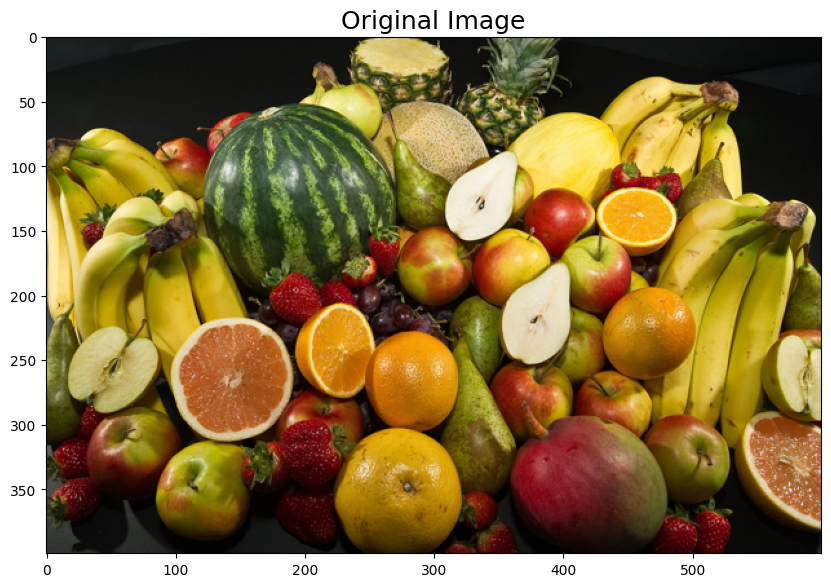

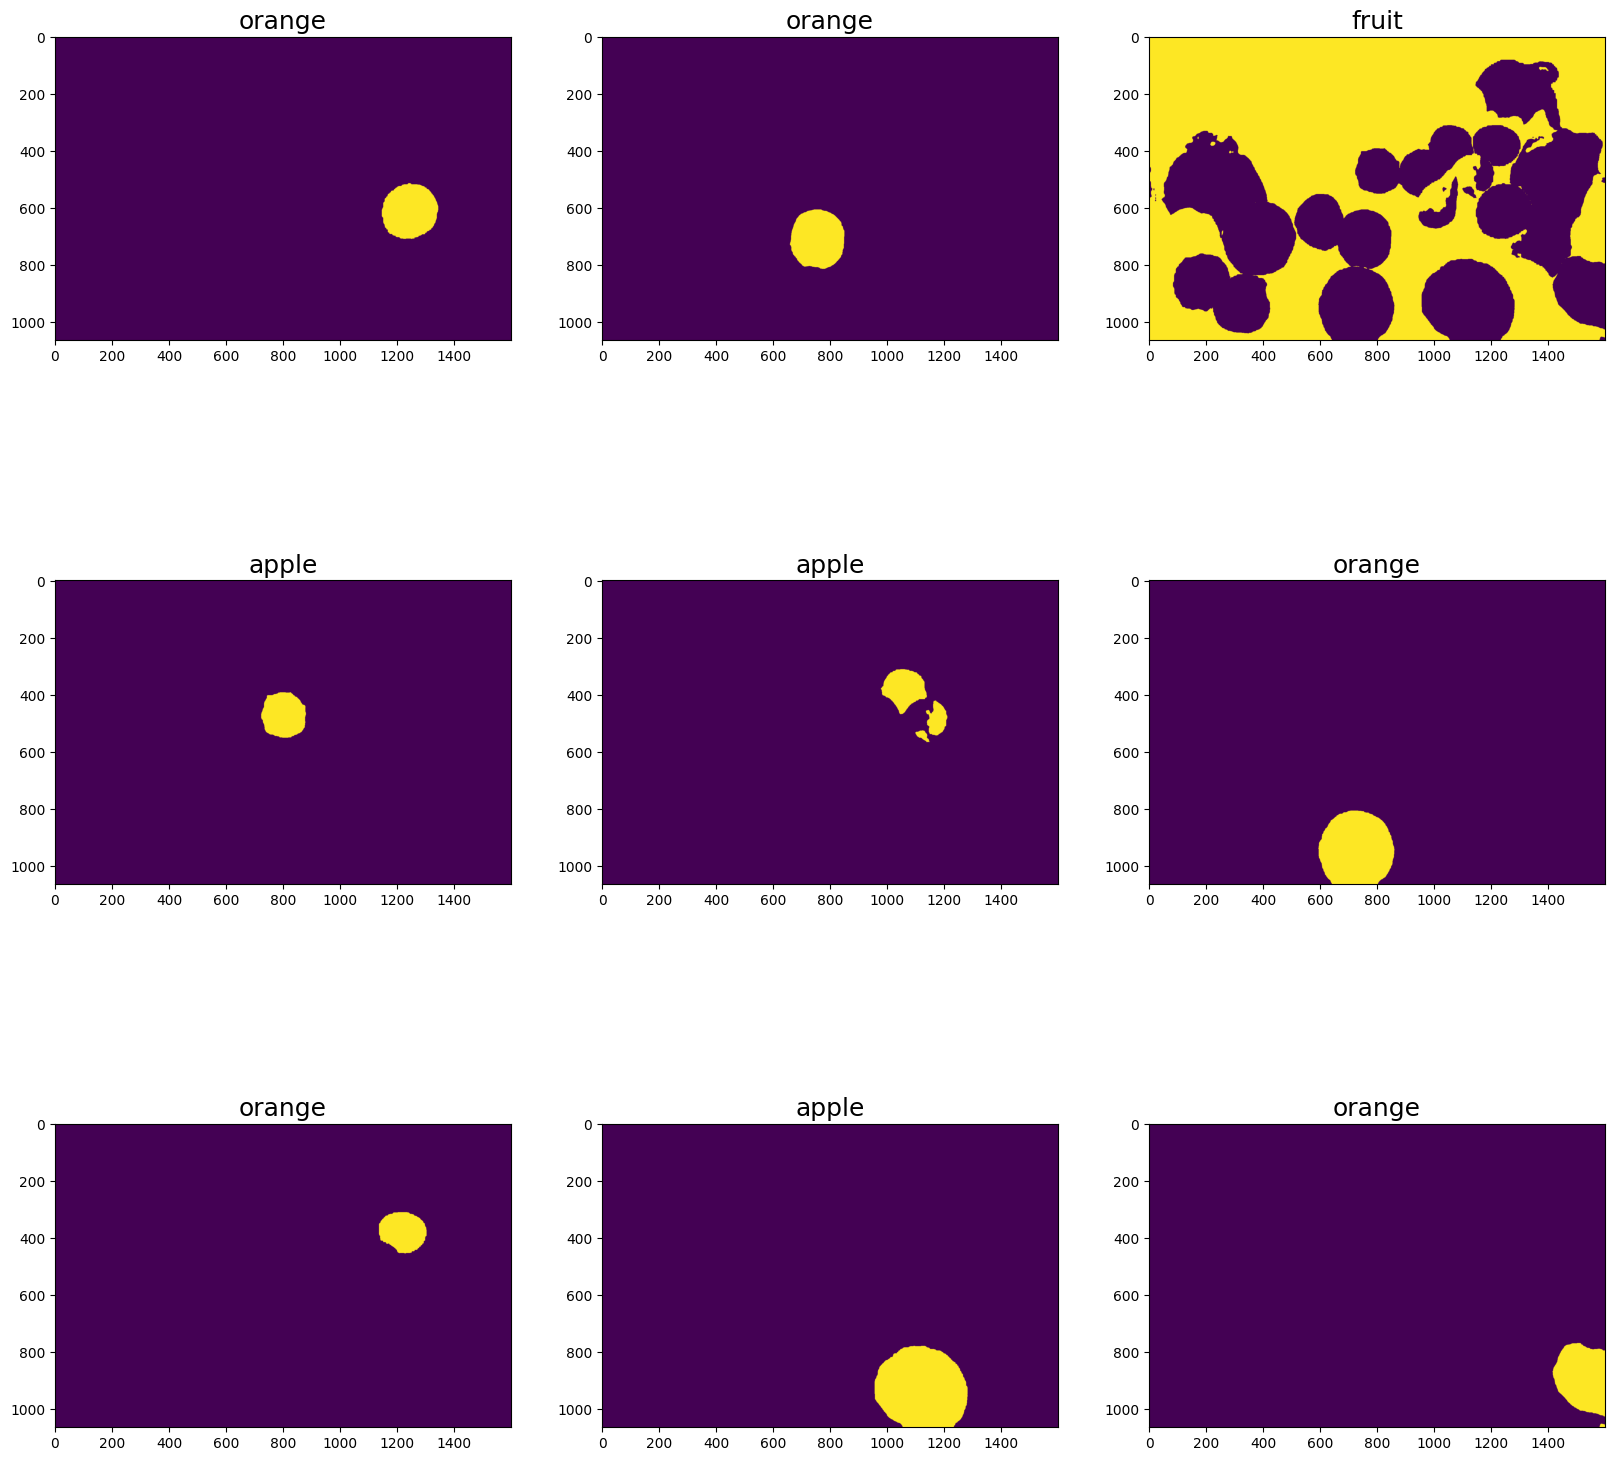

In [18]:
def print_img_and_masks(model_output, original_img_path):

    img_masks_list = [i['mask'] for i in model_output][:9] # Select top 9 results
    masks_labels = [i['label'] for i in model_output][:9] # Select top 9 results

    original_img = Image.open(r"fruits.jpg")
    plt.figure(figsize = (10,10))
    plt.title('Original Image', fontsize=18)
    plt.imshow(original_img.resize((600, 400)));

    # Print Segmentation Masks
    _, axs = plt.subplots(3, 3, figsize=(20, 20)) # 3x3 Grid
    axs = axs.flatten()
    for img, ax, l in zip(img_masks_list, axs, masks_labels):
        ax.set_title(f'{l}', fontsize=18)
        ax.imshow(img)
    plt.show()

img_masks_out = model_img_segm("fruits.jpg", threshold=0.95, mask_threshold=0.7)
print_img_and_masks(img_masks_out, 'fruits.jpg')